# Introduction to definitive screening designs with pydoe

This notebook uses pydoe to construct definitive screening designs. A design matrix is a
practical run sheet:

- each row is one experiment to perform;
- each numerical column is a controllable factor coded as `-1`, `0`, or `+1` for low,
  center, and high;
- each categorical column is coded as `-1` or `+1` for two real alternatives;
- the returned order is the design's standard order, not necessarily the order in which runs
  should be executed.

For field work, preserve a `StandardOrder` column, randomize a separate `RunOrder` when
appropriate, translate coded values to physical settings, and add blank response and notes
columns. A zero is a center setting, not a missing value.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import pydoe

sns.set_theme(style="whitegrid")

In [2]:
def dsd_dataframe(n_num, n_cat=0, *, min_13=True, n_fake_factors=0, method="dsd"):
    """Return a labeled, coded DSD as a pandas DataFrame."""
    design = pydoe.definitive_screening_design(
        n_num,
        n_cat=n_cat,
        method=method,
        min_13=min_13,
        n_fake_factors=n_fake_factors,
    )
    columns = [f"X{i:02d}" for i in range(1, n_num + 1)]
    columns += [f"C{i:02d}" for i in range(1, n_cat + 1)]
    frame = pd.DataFrame(design, columns=columns, index=np.arange(1, len(design) + 1))
    frame.index.name = "Run"
    return frame


def decode_factors(coded, factors):
    """Decode a coded frame using {name: (low, high)} specifications."""
    result = pd.DataFrame(index=coded.index)
    num_column = 0
    cat_column = sum(np.issubdtype(type(levels[0]), np.number) for levels in factors.values())
    for name, levels in factors.items():
        low, high = levels
        is_numeric = np.issubdtype(type(low), np.number) and not isinstance(low, (bool, np.bool_))
        if is_numeric:
            source = coded.iloc[:, num_column]
            result[name] = (low + high) / 2 + source * (high - low) / 2
            num_column += 1
        else:
            source = coded.iloc[:, cat_column]
            result[name] = source.map({-1.0: low, 1.0: high})
            cat_column += 1
    return result

## Numerical, mixed, and augmented designs

`n_fake_factors` enlarges the run matrix while omitting the temporary factor columns from the returned design.

In [3]:
numerical = dsd_dataframe(5)
mixed = dsd_dataframe(5, n_cat=2)
augmented = dsd_dataframe(5, n_cat=2, n_fake_factors=2)

print("Numerical:", numerical.shape)
display(numerical)
print("Mixed:", mixed.shape)
display(mixed)
print("Augmented with two fake factors:", augmented.shape)
display(augmented)

Numerical: (13, 5)


,X01,X02,X03,X04,X05
Run,,,,,
1,0.0,0.0,0.0,0.0,0.0
2,0.0,1.0,1.0,1.0,1.0
3,1.0,0.0,-1.0,1.0,1.0
4,1.0,-1.0,0.0,-1.0,1.0
5,1.0,1.0,-1.0,0.0,-1.0
6,1.0,1.0,1.0,-1.0,0.0
7,1.0,-1.0,1.0,1.0,-1.0
8,0.0,-1.0,-1.0,-1.0,-1.0
9,-1.0,0.0,1.0,-1.0,-1.0


Mixed: (18, 7)


,X01,X02,X03,X04,X05,C01,C02
Run,,,,,,,
1,0.0,0.0,0.0,0.0,0.0,-1.0,-1.0
2,0.0,0.0,0.0,0.0,0.0,1.0,1.0
3,0.0,1.0,1.0,1.0,1.0,1.0,1.0
4,1.0,0.0,-1.0,-1.0,1.0,-1.0,1.0
5,1.0,1.0,0.0,-1.0,-1.0,1.0,-1.0
6,1.0,1.0,1.0,0.0,-1.0,-1.0,1.0
7,1.0,-1.0,1.0,1.0,0.0,-1.0,-1.0
8,1.0,1.0,-1.0,1.0,1.0,1.0,-1.0
9,1.0,-1.0,1.0,-1.0,1.0,1.0,1.0


Augmented with two fake factors: (22, 7)


,X01,X02,X03,X04,X05,C01,C02
Run,,,,,,,
1,0.0,0.0,0.0,0.0,0.0,-1.0,-1.0
2,0.0,0.0,0.0,0.0,0.0,1.0,1.0
3,0.0,1.0,1.0,1.0,1.0,1.0,1.0
4,1.0,0.0,-1.0,-1.0,-1.0,1.0,1.0
5,1.0,-1.0,0.0,-1.0,1.0,-1.0,1.0
6,1.0,-1.0,-1.0,0.0,1.0,1.0,-1.0
7,1.0,-1.0,1.0,1.0,0.0,1.0,-1.0
8,1.0,-1.0,1.0,1.0,-1.0,-1.0,1.0
9,1.0,1.0,-1.0,1.0,-1.0,-1.0,-1.0


## Physical factor names and levels

Pydoe intentionally returns a numerical design matrix. Decoding coded levels is a separate, explicit step.

In [4]:
factors = {
    "Temperature": (30.0, 60.0),
    "Pressure": (1.0, 10.0),
    "Stirring speed": (500.0, 700.0),
    "Solvent": ("Solv-A", "Solv-B"),
    "Vessel": ("1", "2"),
}

coded = dsd_dataframe(3, n_cat=2)
physical = decode_factors(coded, factors)
display(physical)

,Temperature,Pressure,Stirring speed,Solvent,Vessel
Run,,,,,
1,45.0,5.5,600.0,Solv-A,1
2,45.0,5.5,600.0,Solv-B,2
3,45.0,10.0,700.0,Solv-B,2
4,60.0,5.5,500.0,Solv-B,1
5,60.0,1.0,600.0,Solv-B,2
6,60.0,10.0,500.0,Solv-A,2
7,60.0,10.0,700.0,Solv-B,1
8,60.0,1.0,700.0,Solv-A,2
9,45.0,1.0,500.0,Solv-A,1


## Turn the design into an execution sheet

`StandardOrder` keeps a permanent link to the mathematical design. `RunOrder` is the order
used in the laboratory or plant. Randomization protects effect estimates from time trends,
warm-up, drift, and other lurking variables. If unrestricted randomization is unsafe or
impractical, define blocks or document the restriction rather than silently using standard order.

Every row must remain in the run sheet. Do not deduplicate mirrored or center conditions:
replication and foldover structure carry statistical information.

In [5]:
run_sheet = physical.copy()
run_sheet.insert(0, "StandardOrder", run_sheet.index)
run_sheet = run_sheet.sample(frac=1, random_state=2026).reset_index(drop=True)
run_sheet.index = np.arange(1, len(run_sheet) + 1)
run_sheet.index.name = "RunOrder"
run_sheet["Response"] = np.nan
run_sheet["Notes"] = ""
display(run_sheet)

,StandardOrder,Temperature,Pressure,Stirring speed,Solvent,Vessel,Response,Notes
RunOrder,,,,,,,,
1,1,45.0,5.5,600.0,Solv-A,1,NaN,
2,14,30.0,10.0,500.0,Solv-B,1,NaN,
3,12,30.0,1.0,700.0,Solv-B,1,NaN,
4,3,45.0,10.0,700.0,Solv-B,2,NaN,
5,13,30.0,1.0,500.0,Solv-A,2,NaN,
6,10,30.0,5.5,700.0,Solv-A,2,NaN,
7,6,60.0,10.0,500.0,Solv-A,2,NaN,
8,8,60.0,1.0,700.0,Solv-A,2,NaN,
9,4,60.0,5.5,500.0,Solv-B,1,NaN,


## Run-count survey

The DSD run count grows far more slowly than a complete mixed-level factorial. This is the
screening tradeoff: the practitioner runs fewer conditions, but the full quadratic model is
usually not estimable without sparsity, heredity assumptions, or later augmentation. Run count
alone is therefore not a sufficient design-quality criterion.

,n_num,n_cat,n_total,DSD runs,2k+1,full factorial runs
0,1,0,1,5,3,3
1,2,0,2,5,5,9
2,3,0,3,9,7,27
3,4,0,4,9,9,81
4,5,0,5,13,11,243
...,...,...,...,...,...,...
138,7,11,18,38,37,4478976
139,8,11,19,42,39,13436928
140,9,11,20,42,41,40310784
141,10,11,21,50,43,120932352


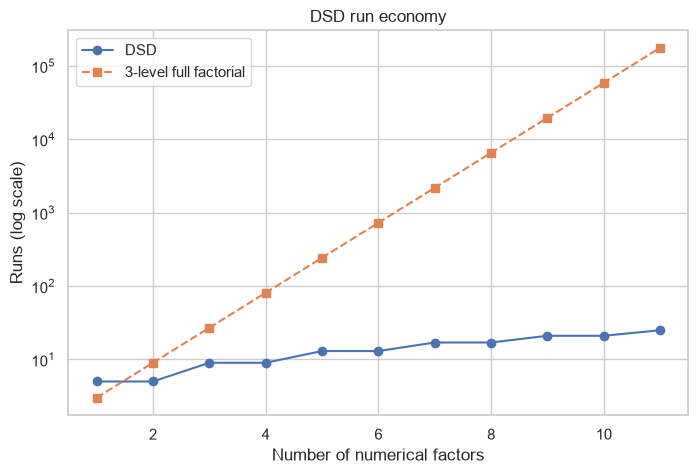

In [6]:
rows = []
for n_cat in range(0, 12):
    for n_num in range(0, 12):
        if n_num + n_cat == 0:
            continue
        design = pydoe.definitive_screening_design(n_num, n_cat=n_cat, min_13=False)
        n_total = n_num + n_cat
        rows.append({
            "n_num": n_num,
            "n_cat": n_cat,
            "n_total": n_total,
            "DSD runs": len(design),
            "2k+1": 2 * n_total + 1,
            "full factorial runs": 3**n_num * 2**n_cat,
        })

run_counts = pd.DataFrame(rows)
display(run_counts)

fig, ax = plt.subplots(figsize=(8, 5))
subset = run_counts.query("n_cat == 0")
ax.semilogy(subset["n_num"], subset["DSD runs"], "o-", label="DSD")
ax.semilogy(subset["n_num"], subset["full factorial runs"], "s--", label="3-level full factorial")
ax.set(xlabel="Number of numerical factors", ylabel="Runs (log scale)", title="DSD run economy")
ax.legend()
plt.show()